## Pipline

* 1- Data Understanding
* 2- Data Cleaning
* 3- EDA
* 4- Regional Analysis
* 5- Trend Analysis with time
* 6- Covid-19 Impact
* 7- Seasonality
* 8- Insights

## Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Unemployment in India.csv")

In [3]:
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [5]:
data.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Data Cleaning

In [6]:
data.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [19]:
data.dropna(inplace = True)

In [20]:
data.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [21]:
data.duplicated().sum()

np.int64(0)

In [39]:
data[' Date']

0       31-05-2019
1       30-06-2019
2       31-07-2019
3       31-08-2019
4       30-09-2019
          ...     
749     29-02-2020
750     31-03-2020
751     30-04-2020
752     31-05-2020
753     30-06-2020
Name:  Date, Length: 740, dtype: object

In [43]:
data.rename(columns={' Date':'Date'},inplace =True)

In [45]:
data['Date']

0       31-05-2019
1       30-06-2019
2       31-07-2019
3       31-08-2019
4       30-09-2019
          ...     
749     29-02-2020
750     31-03-2020
751     30-04-2020
752     31-05-2020
753     30-06-2020
Name: Date, Length: 740, dtype: object

In [46]:
data['Date']=pd.to_datetime(data['Date'])

C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_12264\1428478067.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date']=pd.to_datetime(data['Date'])


In [48]:
data['Year'] = data['Date'].dt.year

In [50]:
data['Month'] = data['Date'].dt.month

In [52]:
data['Month_Name'] = data['Date'].dt.month_name()

In [53]:
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


## EDA  (Exploratory analysis)

In [56]:
data.rename(columns={' Estimated Unemployment Rate (%)':'Estimated Unemployment Rate (%)'},inplace =True)

In [60]:
data['Estimated Unemployment Rate (%)'].max()

76.74

In [61]:
data['Estimated Unemployment Rate (%)'].min()

0.0

In [62]:
data['Estimated Unemployment Rate (%)'].mean()

np.float64(11.787945945945946)

## Regional Analysis

In [68]:
region_Unemployment = data.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_Unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

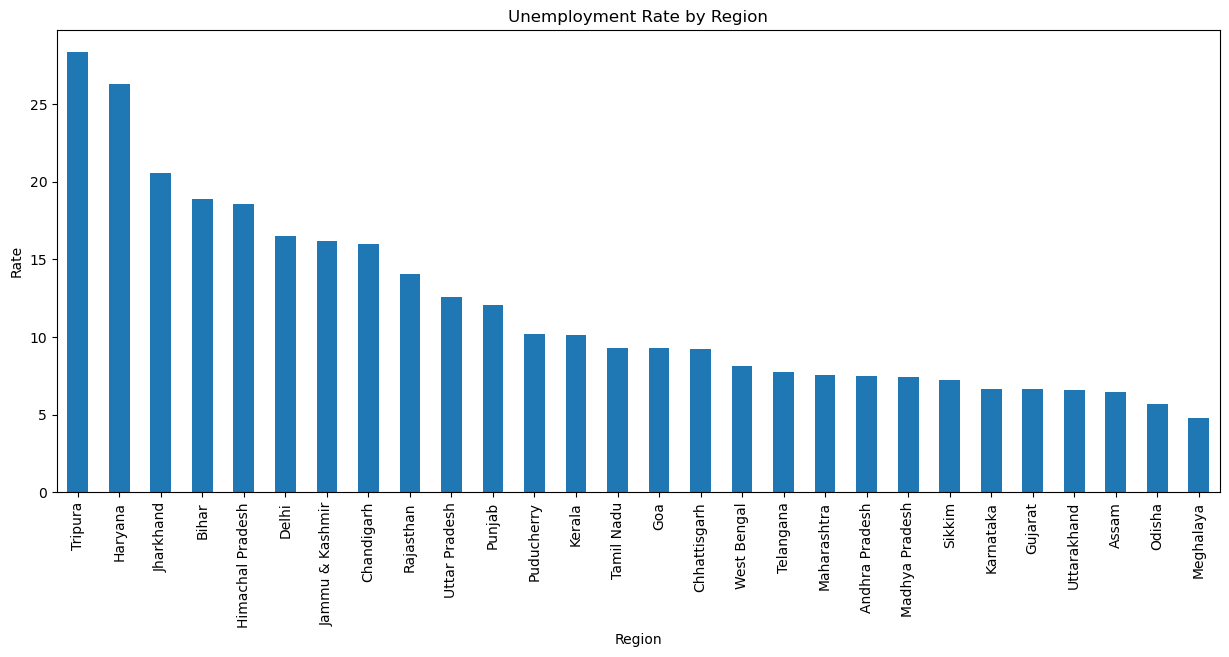

In [90]:
plt.figure(figsize=(15,6))
region_Unemployment.plot(kind='bar')

plt.title('Unemployment Rate by Region')
plt.ylabel('Rate')

plt.show()

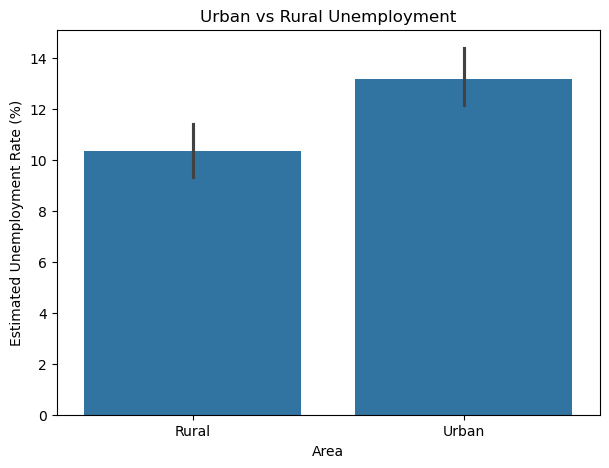

In [91]:
# مقارنة Urban و Rural
plt.figure(figsize=(7,5))
sns.barplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=data
)

plt.title('Urban vs Rural Unemployment')

plt.show()

## Trend Analysis with time

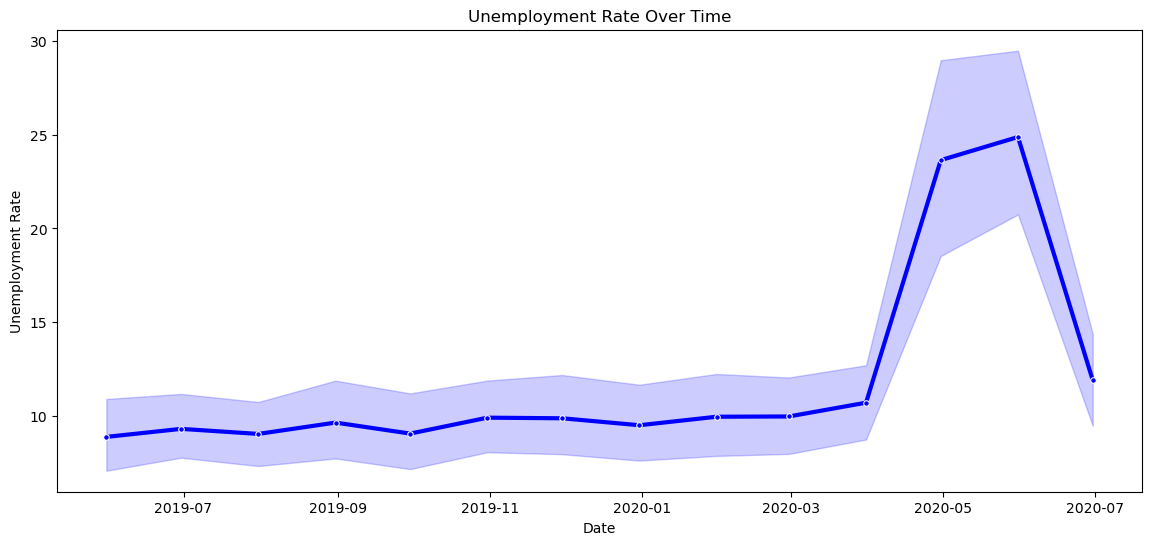

In [74]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data = data,
    linewidth=3,
    linestyle='-',
    marker='o',
    markersize=4,
    color='blue'
)
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.show()
    


## Covid-19 Impact

In [76]:

yearly = data.groupby('Year')['Estimated Unemployment Rate (%)'].mean()

print(yearly)

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


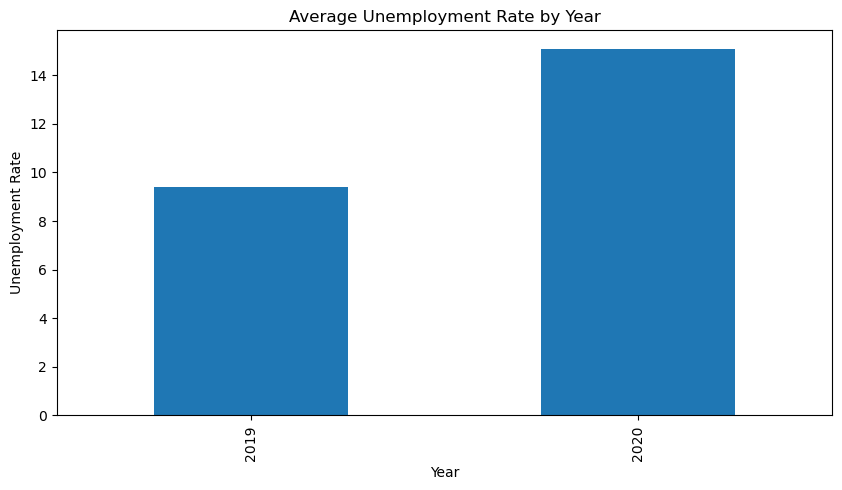

In [77]:
plt.figure(figsize=(10,5))

yearly.plot(kind='bar')

plt.title('Average Unemployment Rate by Year')
plt.ylabel('Unemployment Rate')

plt.show()

Pre-Covid Avg: 9.509533582089553
Covid Avg: 17.774362745098042
Post-Covid Avg: nan


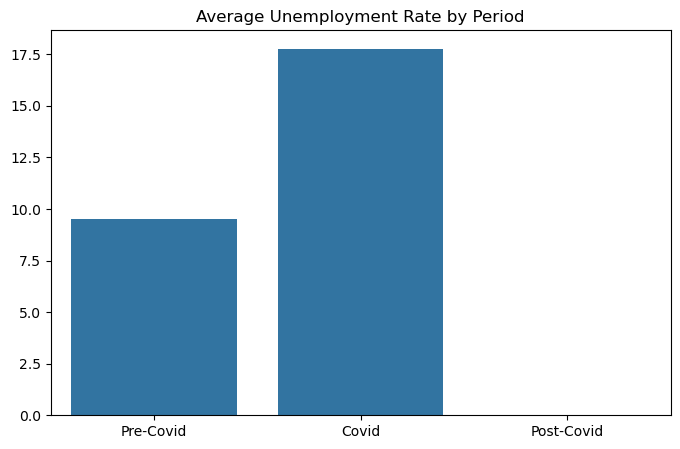

In [92]:
pre_covid = data[data['Date'] < '2020-03-01']
covid = data[(data['Date'] >= '2020-03-01') & (data['Date'] <= '2021-12-31')]
post_covid = data[data['Date'] > '2021-12-31']

print("Pre-Covid Avg:", pre_covid['Estimated Unemployment Rate (%)'].mean())
print("Covid Avg:", covid['Estimated Unemployment Rate (%)'].mean())
print("Post-Covid Avg:", post_covid['Estimated Unemployment Rate (%)'].mean())

# Visualization
labels = ['Pre-Covid', 'Covid', 'Post-Covid']
values = [
    pre_covid['Estimated Unemployment Rate (%)'].mean(),
    covid['Estimated Unemployment Rate (%)'].mean(),
    post_covid['Estimated Unemployment Rate (%)'].mean()
]

plt.figure(figsize=(8,5))
sns.barplot(x=labels, y=values)
plt.title("Average Unemployment Rate by Period")
plt.show()

## Seasonality

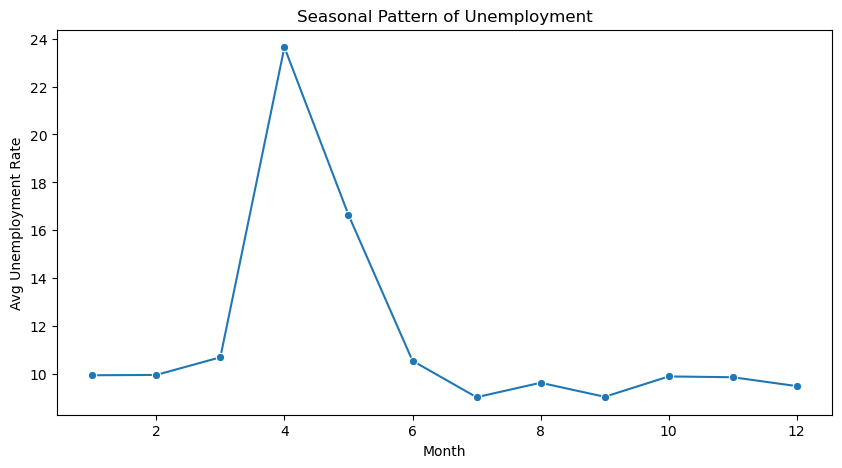

In [89]:
monthly_avg = data.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title("Seasonal Pattern of Unemployment")
plt.xlabel("Month")
plt.ylabel("Avg Unemployment Rate")
plt.show()

## Insights

In [ ]:

# Unemployment increased significantly during Covid-19.
# Urban areas were more affected than rural areas.
# Some regions showed consistently high unemployment rates.
# Unemployment rates differ clearly between regions.
# Some regions consistently show higher unemployment than others.
# Unemployment increased at month 4